# ICAEW Data Analytics Certificate Programme Case Study (Analyst pathway)
## Decision making part 1

Welcome back to the Case Study for the ICAEW Data Analytics Certificate Programme (Analyst pathway). 

We have examined the data through exploratory data analysis to gain a deeper understanding of the data already. Now we will use the skills we have learnt within Unit 4. 


We'll use the cleaned Sales dataset provided. The structure of this notebook is as follows:

- We will create a time series plot to understand how sales and profits have changed over time.
- We will see that the sales have seasonality and a trend.
- We will use techniques covered in the course to select an optimal time series model.
- We will use this model to get a prediction of the sales' future performance in terms of profits.
- Finally we will fit a model to predict total sales and use this to estimate the sales growth for the next year.


## Setting up the environment

First, we will load the prepared sales data as we have done previously.

In [1]:
# Load the required packages
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import matplotlib as mpl
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns             # statistical data visualization

In [3]:
# Load the sales data as sales
sales = pd.read_excel("C:\\Users\\0028773\\OneDrive - DEME\\Documents\\George's Personal Documents\\ICAEW Data Analytics Certificate\\Case Study\\3. Decision making - task part 1\\Sales2023.xlsx"
                     )

## Preparing the data for analysis

In this Notebook, we will focus on predicting the future profit and sales of the company. First, we need to prepare the data for the analysis, therefore we select only the relevant columns and aggregate by our selected date column. We will forecast the profits of the company before moving onto sales.


In [5]:
# Select profit and order date from sales and call this dataset profits 
profits = sales[['Order Date', 'Profit']]

In [6]:
# Aggregate the data by order date and sum to get total profits
profits = profits.groupby('Order Date').sum()

# Reset the index
profits = profits.reset_index()

# Set the index to be Order Date
profits = profits.set_index('Order Date')

## Plotting the time series

From the time plot, we can get a visual description of the time series, which allows us to pick out any prominent features of the sales data. We expect a company that appears to be a promising investment would demonstrate growth and increasing profits year on year.


In [7]:
# Resample the profits specifiying 'MS' then sum to get a total monthly figure and call this aggprofits
aggprofits = profits.resample('MS').sum()

In [ ]:
# Load the visualisation packages



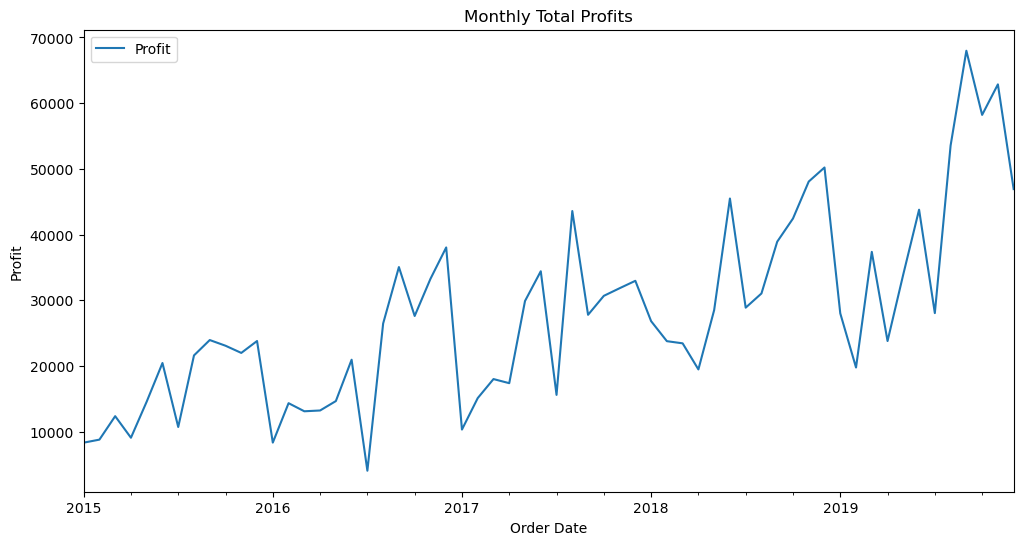

In [8]:
# Create a time plot of aggprofits
aggprofits.plot(figsize=(12, 6))
plt.title('Monthly Total Profits')
plt.xlabel('Order Date')
plt.ylabel('Profit')
plt.show()


## Examine the patterns in the data

We've examined the overall patterns in the data through the time plot. To clearly identify if the company appears to exhibit increasing profits, it is helpful to decompose the time series into its individual elements. Then, we can isolate the exact trend of sales from other variation in the time series. This allows us to identify if there is growth within the company as opposed to just random fluctuations known as noise. 

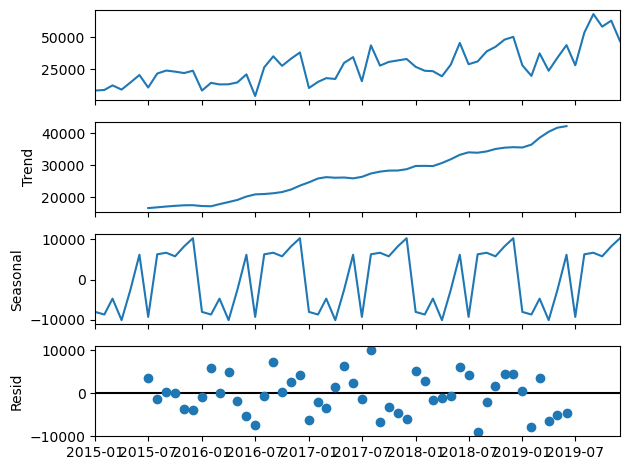

In [9]:
# Import the required package
import statsmodels.api as sm

# Examine the trend, seasonal variation and noise in sales
decomposition = sm.tsa.seasonal_decompose(aggprofits, model='additive')
fig = decomposition.plot()
plt.show()


We have isolated the individual components of the time series data. We can examine these and other patterns in the data further by plotting the Autocorrelation Functions and the Partial Autocorrelation Functions. 

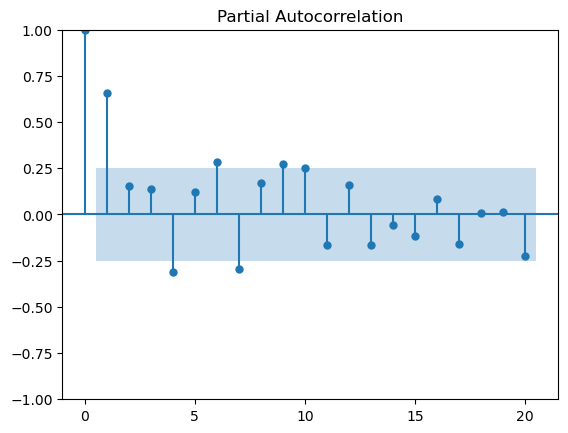

In [10]:
# Import the required package
from statsmodels.graphics.tsaplots import plot_pacf

# Visualise a PACF plot of profits
plot_pacf(aggprofits, lags=20)
plt.show()


## Modelling the company's performance

Now we understand the patterns and trends in the profits of the company, we can fit a time series model. This can be used to produce a prediction for the company's future performance. Therefore, we should try to develop as accurate model as possible to deliver more trustworthy predictions.

Using the techniques we have learnt in this course, select an appropriate model to model the company's profits. This model can then be fitted to the data and its performance and fit can be measured. It is good practice to check your model's fit before generating predictions. The fit of the model should be assessed in terms of the coefficients. This informs us whether predictions based on these models can be trusted.

We practised creating and selecting ARIMA time series models in the time series analysis section in Module 1 of Unit 4: Decision Making. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

The following is assessed in the assessment.

To prepare our data for modelling we first need to:
- Select only the Profit and Order Date columns
- Group by Order Date, sum and reset the index
- Set the index to be Order Date
- Resample Profit and then sum, specifying MS as our resampling method.

This final dataset will then be used to test which models provide the optimal Akaike information criterion (AIC) score.

In [11]:
# Import the required package
import itertools

# Select a time series model
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]      
            
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(aggprofits,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)
            results = mod.fit()
            print('ARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

ARIMA(0, 0, 0)x(0, 0, 0, 12) - AIC:1391.3548423982281
ARIMA(0, 0, 0)x(0, 0, 1, 12) - AIC:1102.0523251204313
ARIMA(0, 0, 0)x(0, 1, 0, 12) - AIC:1007.0561933486258


C:\Users\0028773\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(0, 0, 0)x(0, 1, 1, 12) - AIC:1657.2794046616973
ARIMA(0, 0, 0)x(1, 0, 0, 12) - AIC:1011.8514559534367
ARIMA(0, 0, 0)x(1, 0, 1, 12) - AIC:989.6862312720637
ARIMA(0, 0, 0)x(1, 1, 0, 12) - AIC:778.9330651987578


C:\Users\0028773\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(0, 0, 0)x(1, 1, 1, 12) - AIC:1554.693745461259
ARIMA(0, 0, 1)x(0, 0, 0, 12) - AIC:1336.589222535199
ARIMA(0, 0, 1)x(0, 0, 1, 12) - AIC:1054.5162188415775
ARIMA(0, 0, 1)x(0, 1, 0, 12) - AIC:977.5441616139767


...

C:\Users\0028773\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1, 1, 0)x(1, 1, 1, 12) - AIC:1239.6581297192195
ARIMA(1, 1, 1)x(0, 0, 0, 12) - AIC:1219.7057309763761
ARIMA(1, 1, 1)x(0, 0, 1, 12) - AIC:962.0655949989668
ARIMA(1, 1, 1)x(0, 1, 0, 12) - AIC:951.2232402054112


C:\Users\0028773\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1, 1, 1)x(0, 1, 1, 12) - AIC:956.4294288339756
ARIMA(1, 1, 1)x(1, 0, 0, 12) - AIC:974.9604719080227
ARIMA(1, 1, 1)x(1, 0, 1, 12) - AIC:952.2498699385567
ARIMA(1, 1, 1)x(1, 1, 0, 12) - AIC:714.5229882683
ARIMA(1, 1, 1)x(1, 1, 1, 12) - AIC:1138.0309698959957


C:\Users\0028773\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


##### <b>Please take a note of the optimal time series model for modelling the company's profits.</b>

<i>Select here to type your answer:

In [12]:
# Create the selected model and call it mod1
mod1 = sm.tsa.statespace.SARIMAX(aggprofits,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)


In [13]:
# Fit the model and call it results1
results1 = mod1.fit()

                                      SARIMAX Results                                      
Dep. Variable:                              Profit   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                -353.261
Date:                             Mon, 27 Apr 2026   AIC                            714.523
Time:                                     21:58:48   BIC                            720.628
Sample:                                 01-01-2015   HQIC                           716.605
                                      - 12-01-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2584      0.257      1.006      0.314      -0.245       0.762
ma.L1         -0.9999      

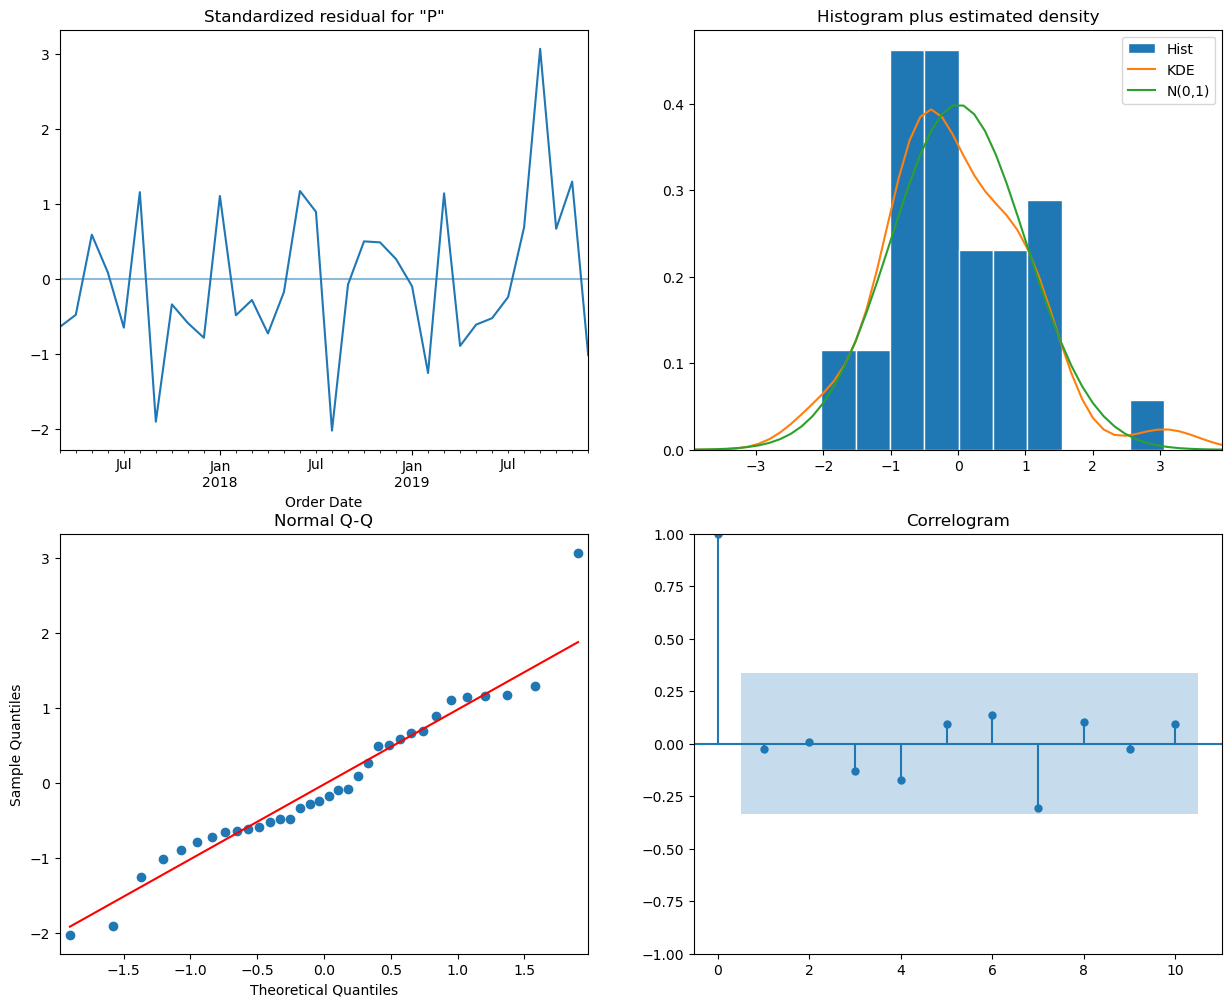

In [14]:
# Examine the fit of the model
print(results1.summary())
results1.plot_diagnostics(figsize=(15, 12))
plt.show()

In addition to examining the appropriateness of the model and the goodness of fit, we can quantify its accuracy by contrasting predictions for the prior year with the actuals. This allows us to understand the degree of accuracy the model has before predicting unknowns.

The inclusion of confidence intervals in predictions against actuals allows a visual representation of the uncertainty in the model's estimations and are useful to determine the accuracy of the model.

We practised generating predictions from time series models in the time series analysis section in Module 1 of Unit 4: Decision Making. If you purchased the learning and certificate Analyst Pathway, we recommend you revisit this content if you are struggling to complete these tasks.


The following is assessed in the assessment.

By fitting our time series model, we can use the results of this to generate predictions from ‘2019-01-01’ by specifying this datetime as the start date in the get_prediction command.

In [35]:
# Generate predictions for the prior year and call it pred1
pred1 = results1.get_prediction(start=pd.to_datetime('2019-01-01'), dynamic=False)

# Generate confidence intervals and call it pred_ci
pred_ci = pred1.conf_int()

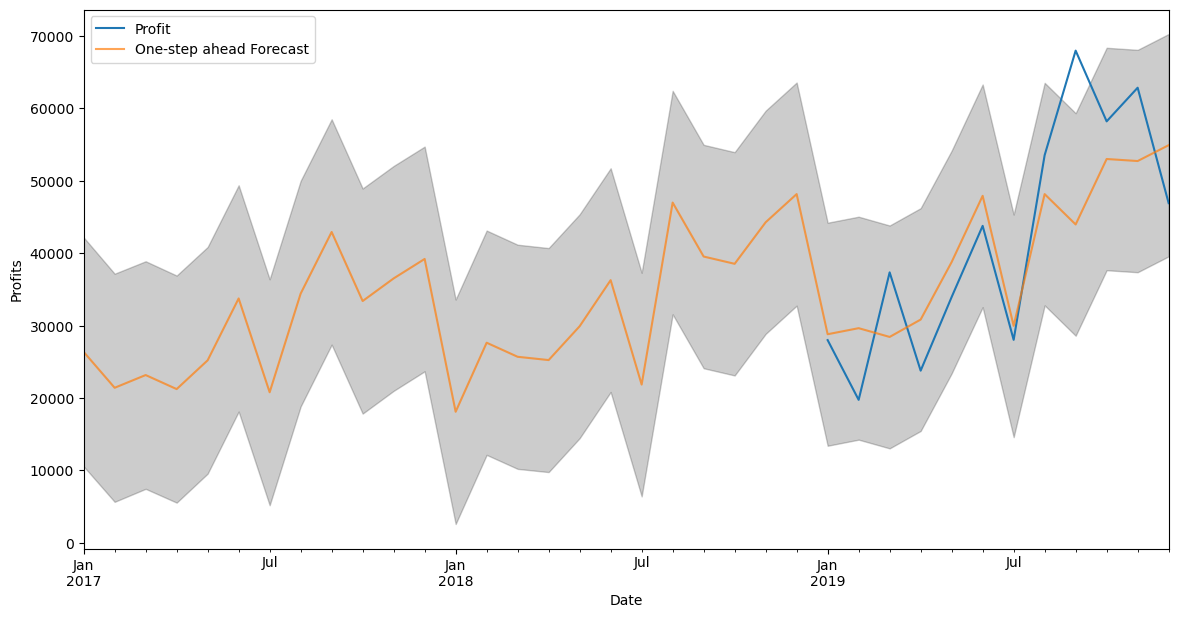

In [16]:
# Plot the actuals with the label Observed
ax = aggprofits['2019':].plot(label='Observed', figsize=(14, 7))

# Plot the predictions with the label Forecast
pred1.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7)

# Plot the confidence intervals
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Date')
ax.set_ylabel('Profits')
plt.legend()
plt.show()

##### <b>Please take a note of the key features in the graph above.</b>

<i>Select here to type your answer:
Strong Seasonality: Notice the "spiky" pattern that repeats every year. Profits consistently dip around January and July and peak in the late spring and end-of-year periods.
Upward Trend: If you look at the orange forecast line from 2017 to 2019, it is gradually sloping upwards, suggesting the business is growing over time.
Model Accuracy: The blue "Observed" line stays mostly within the grey shaded area (the confidence interval). This means your model is "surprised" by very few of the actual data points—it’s doing a good job of capturing the reality of the business.
Late 2019 Volatility: Toward the end of 2019, the actual profit (blue) starts swinging more wildly, pushing toward the edges of your confidence interval.

As well as producing a visual representation of the accuracy of the model, it is possible to quantify the model's accuracy, numerically, using the Mean Squared Error or the Root Mean Squared Error.

In [17]:
# Import the required package
import numpy as np

# Calculate the error rate of the model
y_forecasted = pred1.predicted_mean
y_truth = aggprofits['2019-01-01':]['Profit']


## Predicting the company's performance

Now we have checked whether our model is suitable and determined how accurate it is, we can generate predictions for the company's performance in the next few years. This will allow us to understand the likelihood of the company being a good investment in terms of profits and we can examine the likely return on investment.

We practised creating and selecting ARIMA time series models in the time series analysis section in Module 1 of Unit 4: Decision Making. We covered slicing data in Module 1 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

In [18]:
# Generate the predictions for 5 years' time and call it pred_uc1
pred_uc1 = results1.get_forecast(steps=60)

# Generate confidence intervals and call it pred_ci1
pred_ci1 = pred_uc1.conf_int()

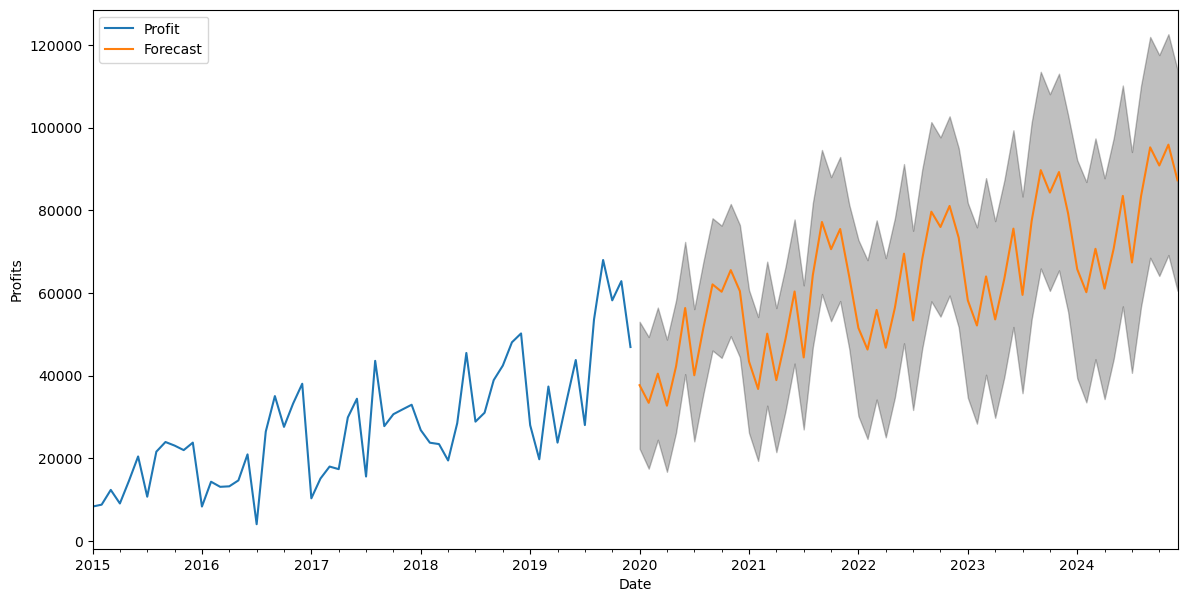

In [19]:
# Plot the actuals with the label Observed
ax = aggprofits.plot(label='Observed', figsize=(14, 7))

# Plot the predictions with the label Forecast
pred_uc1.predicted_mean.plot(ax=ax, label='Forecast')

# Plot the confidence intervals
ax.fill_between(pred_ci1.index,
                pred_ci1.iloc[:, 0],
                pred_ci1.iloc[:, 1], color='k', alpha=.25)

ax.set_xlabel('Date')
ax.set_ylabel('Profits')
plt.legend()
plt.show()

Now that we have generated and plotted our predictions, we can calculate the forecasted profits for next year by using the predicted mean of our predictions.

In [20]:
# Examine your predicted mean figures for your model
print(pred_uc1.predicted_mean)

2020-01-01    37682.298468
2020-02-01    33414.733390
2020-03-01    40471.652492
2020-04-01    32721.205069
2020-05-01    42224.083549
2020-06-01    56351.489436
2020-07-01    40086.155512
2020-08-01    51572.304842
2020-09-01    62072.593819
2020-10-01    60288.598633
2020-11-01    65525.708541
2020-12-01    60443.535055
2021-01-01    43421.835285
2021-02-01    36762.810986
2021-03-01    50154.707192
2021-04-01    38906.354424
2021-05-01    48810.626744
2021-06-01    60354.253729
2021-07-01    44402.768987
2021-08-01    64309.140943
2021-09-01    77173.351604
2021-10-01    70593.598858
2021-11-01    75476.170543
2021-12-01    63873.298798
2022-01-01    51528.361630
2022-02-01    46305.526003
2022-03-01    55892.957440
2022-04-01    46745.268562
2022-05-01    56408.484175
2022-06-01    69503.797242
2022-07-01    53363.830658
2022-08-01    68213.445533
2022-09-01    79658.005165
2022-10-01    75958.340284
2022-11-01    81053.829577
2022-12-01    73366.957273
2023-01-01    58213.394555
2

The following is assessed in the assessment.

To predict profit for the next 5 years, we can use the get forecast command and specify 50 steps. We can then use the predicted mean command from this forecast to obtain the predicted profit values for each month. For the next year we can sum the first 12 estimates.

In [21]:
# Sum the first 12 estimates to produce a total expected value for 2020
total_profit_2020 = pred_uc1.predicted_mean[:12].sum()
print(total_profit_2020)

582854.3588061044


##### <b>Please take a note of the estimated total profits of the company for next year.</b>

<i>Select here to type your answer: 582854.3588061044

## Deeper further analysis

Now we have a visual representation of the company's estimated performance in terms of profits, we may want to investigate further. In addition to predicting the overall performance of the company, we may want to consider future sales growth.

In [22]:
# Select sales and order date from the sales data and call this dataset salesonly 
salesonly = sales[['Order Date', 'Sales']]

In [23]:
# Aggregate the data by order date and sum to get sales value
salesonly = salesonly.groupby('Order Date').sum()
# Reset the index 
salesonly = salesonly.reset_index()
# Set the index as Order Date
salesonly = salesonly.set_index('Order Date')

In [24]:
# Resample the sales specifying MS and summing to get total monthly sales figures and call this aggsales
aggsales = salesonly.resample('MS').sum()

The optimal ARIMA model for modelling the total sales has order (1,1,0) and seasonal order (1,1,0,12). Using this model we can estimate the total sales for the next 5 years.

We practised forecasting predictions from time series models in the time series analysis section in Module 1 of Unit 4: Decision Making. We covered slicing data in Module 1 of Unit 3: Analysing the Data. If you purchased the learning and certificate Analyst Pathway, we strongly recommend you revisit this content if you are struggling to complete these tasks.

In [27]:
# Create the selected model and call it mod2
mod2 = sm.tsa.statespace.SARIMAX(aggsales,
                                order=(1, 1, 0),
                                seasonal_order=(1, 1, 0, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)

In [28]:
# Fit the model and call it results2
results2 = mod2.fit()

In [31]:
# Generate the predictions for 5 years' time and call it pred_uc2
pred_uc2 = results2.get_forecast(steps=60)
pred_ci2 = pred_uc2.conf_int()

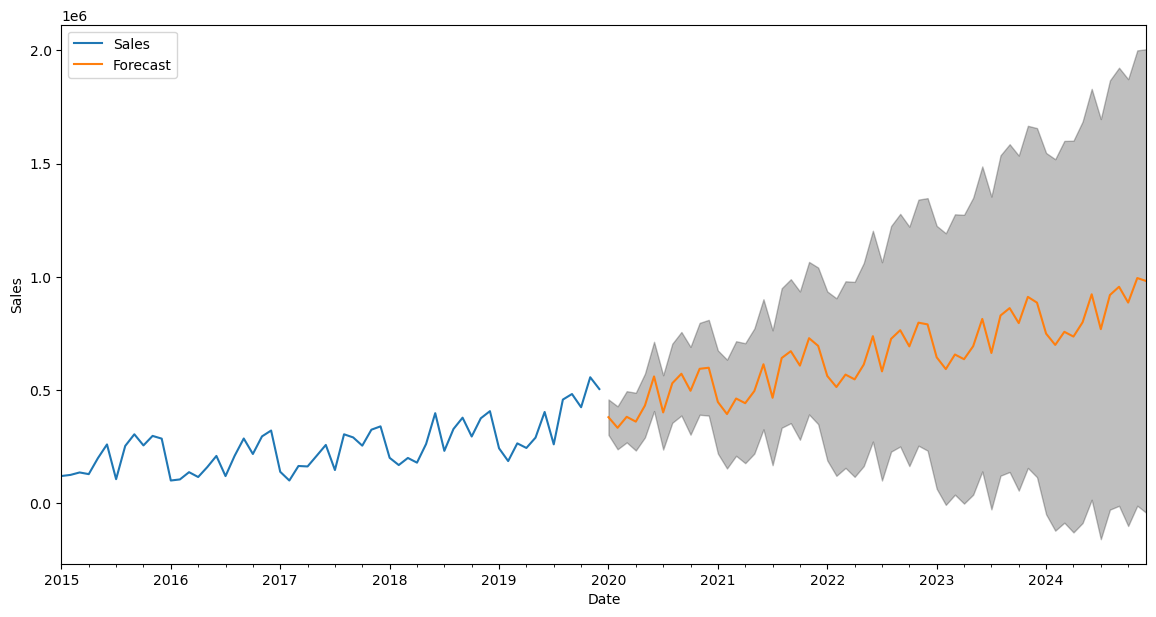

In [32]:
# Plot the actuals with the label Observed
ax = aggsales.plot(label='Observed', figsize=(14, 7))

# Plot the predictions with the label Forecast
pred_uc2.predicted_mean.plot(ax=ax, label='Forecast')

# Plot the confidence intervals
ax.fill_between(pred_ci2.index,
                pred_ci2.iloc[:, 0],
                pred_ci2.iloc[:, 1], color='k', alpha=.25)

ax.set_xlabel('Date')
ax.set_ylabel('Sales')
plt.legend()
plt.show()

As well as identifying if the predicted sales of the company next years are likely to be promising, we should also consider if the model suggests there is a promising growth in sales. The total sales for the previous year are £4299865.87. If we consider the estimated total sales for the next year we can examine the growth rate.

In [33]:
# Sum the first 12 estimates to produce a total expected value for 2020 and save this as sales2020
sales2020 = pred_uc2.predicted_mean[:12].sum()
print(f"Total Expected Sales for 2020: £{sales2020:,.2f}")

Total Expected Sales for 2020: £5,624,339.20


The following is assessed in the assessment.

To estimate the growth rate for sales for the next year, we first need to create a time series model to predict the sales value. We will use the get forecast command to generate the predictions and sum the first 12 entries of predicted mean to get a total sales value estimate for next year. We can then use this value to estimate the sales growth.

In [34]:
# Divide sales2020 by 4299865.87 and then minus 1 to examine the growth rate
growth_rate = (sales2020 / 4299865.87) - 1

# Display as a percentage
print(f"Growth Rate: {growth_rate:.2%}")


Growth Rate: 30.80%


##### <b>Please take a note of the predicted growth rate for the company's sales for next year.</b>

<i>Select here to type your answer:30.80%

##### Assessment guidance

You are ready to take the assessment.

Remember, you should have fully completed your task and recorded your answers in Jupyter Notebook before moving on to the assessment. You can keep your Jupyter Notebook open in a separate browser window to refer to as you take the assessment.  

You will receive a score following completion of the assessment. If you have scored below the target mark of 60% for the section, you are recommended to refresh your knowledge in the course content (if purchased) and rework your Jupyter Notebook before re-attempting the assessment. You have a maximum of three assessment attempts.

You should aim to achieve a target score of 60% in each section of the case study. To pass the case study and be awarded the ICAEW Certificate, you are required to achieve a pass mark of 60% overall, averaged over all five sections, so do not be disheartened if you score below 60% in any one section, as a higher score in one or more of the other sections will contribute to the overall pass mark of 60%.

IMPORTANT: When submitting to the assessment portal, please do not navigate away from it until you have submitted all of your answers for that task. In between any of your 3 assessment attempts (but not during an attempt) you may navigate back to the course content, if you have purchased it, to refresh your knowledge and revisit your Jupyter Notebook to rework your analysis.